In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import statistics as st

import functools as ft

import scipy as sc
import cartopy.crs as ccrs


In [2]:
path_name = './data/mslp.mon.mean.nc' 
ds = xr.open_dataset(path_name, decode_timedelta=True)

In [3]:
ds

<xarray.Dataset> Size: 24MB
Dimensions:    (time: 564, nbnds: 2, lat: 73, lon: 144)
Coordinates:
  * time       (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 9kB ...
    mslp       (time, lat, lon) float32 24MB ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [4]:
mn = ds.mean(dim = "time")

In [5]:
mn.mslp.lat

<xarray.DataArray 'lat' (lat: 73)> Size: 292B
array([ 90. ,  87.5,  85. ,  82.5,  80. ,  77.5,  75. ,  72.5,  70. ,  67.5,
        65. ,  62.5,  60. ,  57.5,  55. ,  52.5,  50. ,  47.5,  45. ,  42.5,
        40. ,  37.5,  35. ,  32.5,  30. ,  27.5,  25. ,  22.5,  20. ,  17.5,
        15. ,  12.5,  10. ,   7.5,   5. ,   2.5,   0. ,  -2.5,  -5. ,  -7.5,
       -10. , -12.5, -15. , -17.5, -20. , -22.5, -25. , -27.5, -30. , -32.5,
       -35. , -37.5, -40. , -42.5, -45. , -47.5, -50. , -52.5, -55. , -57.5,
       -60. , -62.5, -65. , -67.5, -70. , -72.5, -75. , -77.5, -80. , -82.5,
       -85. , -87.5, -90. ], dtype=float32)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
Attributes:
    units:               degrees_north
    actual_range:        [ 90. -90.]
    long_name:           Latitude
    standard_name:       latitude
    axis:                Y
    coordinate_defines:  point

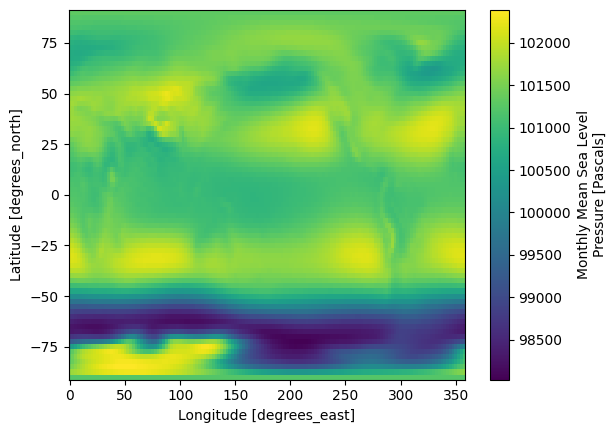

In [6]:
mn.mslp.plot.pcolormesh(x="lon", y="lat")

This is the arithmetic mean values over the period (1979-2025). The water souraounding Antartica show a much lower average, the equator are netutral and we have two srtreeks of higher pressure north and south of the tropics.

Using the package Cartopy we can plot these values on a globe:

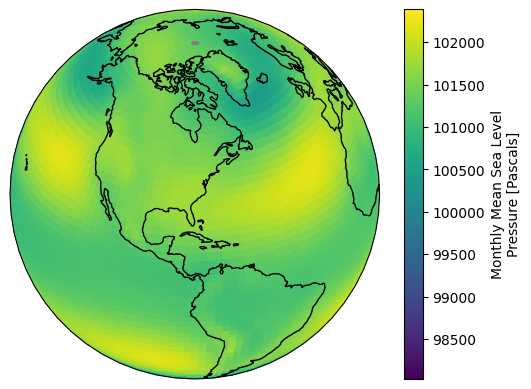

In [7]:

p = mn.mslp.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-80, 35), facecolor="gray"),
    transform=ccrs.PlateCarree(),
)
p.axes.set_global()

p.axes.coastlines();

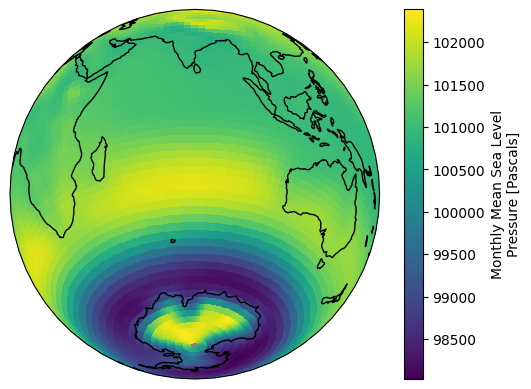

In [8]:
p = mn.mslp.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(80, -35), facecolor="gray"),
    transform=ccrs.PlateCarree(),
)
p.axes.set_global()

p.axes.coastlines();

We now see that the high pressure areas ar over the Atlantic, Pacific and Indian Ocean. The low pressures clealy suraound the Antartic. 

In [9]:
ds79 = ds.sel(time=slice("1979-01-01", "1999-12-01"))

In [10]:
ds00 = ds.sel(time=slice("2000-01-01", "2025-12-01"))

In [11]:
ds79

<xarray.Dataset> Size: 11MB
Dimensions:    (time: 252, nbnds: 2, lat: 73, lon: 144)
Coordinates:
  * time       (time) datetime64[ns] 2kB 1979-01-01 1979-02-01 ... 1999-12-01
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 4kB 1979-01-01 ... 2000-01-01
    mslp       (time, lat, lon) float32 11MB 1.022e+05 1.022e+05 ... 9.948e+04
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [12]:
mean79 = ds79.mean(dim = "time")

In [13]:
mean00 = ds00.mean(dim = "time")

In [14]:
dif = mean00 - mean79

In [15]:
dif

<xarray.Dataset> Size: 43kB
Dimensions:    (lat: 73, lon: 144, nbnds: 2)
Coordinates:
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (nbnds) timedelta64[ns] 16B 8583 days 09:45:56.043956044 8583 ...
    mslp       (lat, lon) float32 42kB 4.336 4.336 4.336 ... -99.8 -99.8 -99.8
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

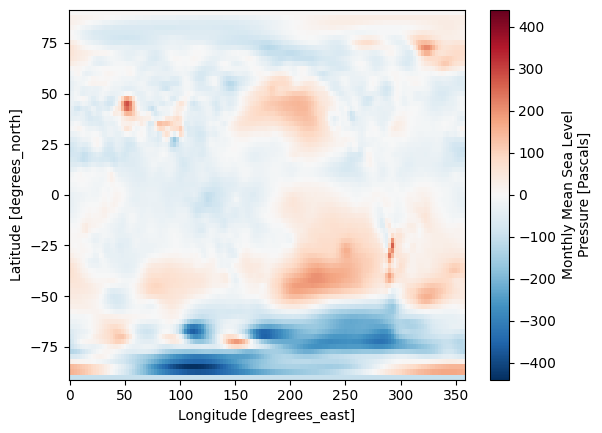

In [16]:
dif.mslp.plot.pcolormesh(x="lon", y="lat")

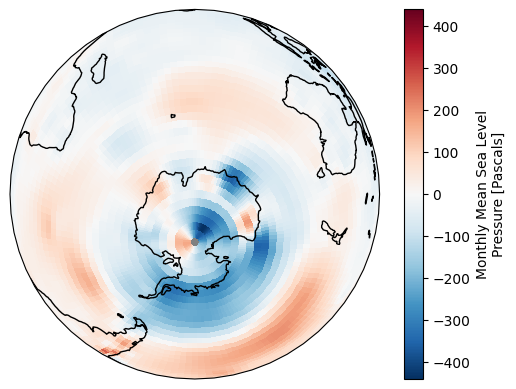

In [17]:
p = dif.mslp.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(80, -75), facecolor="gray"),
    transform=ccrs.PlateCarree(),
)
p.axes.set_global()

p.axes.coastlines();

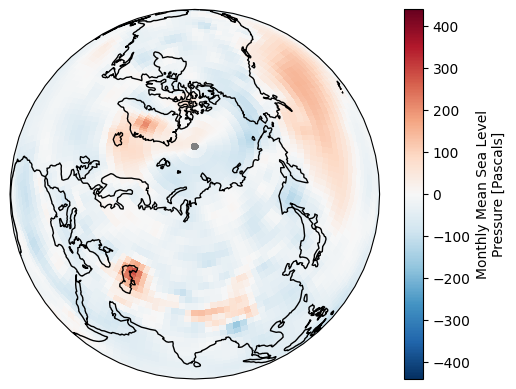

In [18]:
p = dif.mslp.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(80, 75), facecolor="gray"),
    transform=ccrs.PlateCarree(),
)
p.axes.set_global()

p.axes.coastlines();

We see larger difference between the first and last period in the Antartic region. The question is 1/ how reliable the original data is and 2/ is the difference significant?  There are two outliers, one on Greenland and one around the Kaspian see .... could this be true or is it an error in measuement?  

Where does this data come from, what is the accuracy? 

In [27]:
a = ds79["mslp"]
b = ds00["mslp"]

tstat, pval = sc.stats.ttest_ind(
    a,
    b,
    axis=0,          # test along time dimension
    equal_var=False,
    nan_policy="omit"
)

# Convert back to xarray DataArray
pval = xr.DataArray(
    pval,
    coords={"lat": a.lat, "lon": a.lon},
    dims=("lat", "lon"),
)

tstat = xr.DataArray(
    tstat,
    coords={"lat": a.lat, "lon": a.lon},
    dims=("lat", "lon"),
)

In [31]:
tstat


<xarray.DataArray (lat: 73, lon: 144)> Size: 42kB
array([[-0.08102001, -0.08102001, -0.08102001, ..., -0.08102001,
        -0.08102001, -0.08102001],
       [-0.48439166, -0.45600885, -0.42735437, ..., -0.55666   ,
        -0.5363233 , -0.5074394 ],
       [-0.5334472 , -0.46508086, -0.38977772, ..., -0.68494666,
        -0.6449578 , -0.5904295 ],
       ...,
       [-1.7068448 , -1.6042304 , -1.5003026 , ..., -1.9955018 ,
        -1.905166  , -1.807023  ],
       [-1.7703581 , -1.6864609 , -1.5956355 , ..., -1.9860437 ,
        -1.9224399 , -1.8489264 ],
       [ 1.3611789 ,  1.3611789 ,  1.3611789 , ...,  1.3611789 ,
         1.3611789 ,  1.3611789 ]], shape=(73, 144), dtype=float32)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

In [33]:
pval

<xarray.DataArray (lat: 73, lon: 144)> Size: 42kB
array([[0.93545717, 0.93545717, 0.93545717, ..., 0.93545717, 0.93545717,
        0.93545717],
       [0.6283093 , 0.6485716 , 0.66929585, ..., 0.5779962 , 0.5919617 ,
        0.61205906],
       [0.5939464 , 0.6420635 , 0.6968566 , ..., 0.4936755 , 0.5192321 ,
        0.55515313],
       ...,
       [0.08840877, 0.10923056, 0.13410315, ..., 0.04647546, 0.05727376,
        0.07129868],
       [0.0772182 , 0.09227107, 0.11114182, ..., 0.04752123, 0.05506331,
        0.06500155],
       [0.17404337, 0.17404337, 0.17404337, ..., 0.17404337, 0.17404337,
        0.17404337]], shape=(73, 144), dtype=float32)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

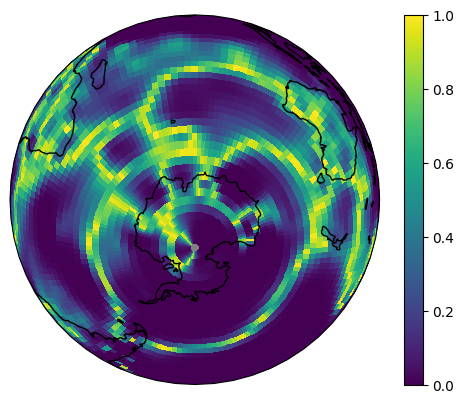

In [35]:
p = pval.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(80, -75), facecolor="gray"),
    transform=ccrs.PlateCarree(),
)
p.axes.set_global()

p.axes.coastlines();

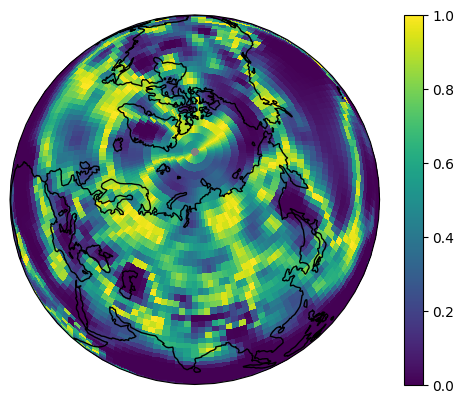

In [36]:
p = pval.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(80, 75), facecolor="gray"),
    transform=ccrs.PlateCarree(),
)
p.axes.set_global()

p.axes.coastlines();